<a href="https://colab.research.google.com/github/Jorj91/Project_Explainable_AI_Banking_Model/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Interpretation of a Neural Network for Regulatory Compliance in Banking**


**Banca Virtuosa**, a leading institution in the financial sector, has identified the need to improve the transparency and interpretability of the artificial intelligence models used in its systems. To achieve this goal, Banca Virtuosa has launched a project aimed at implementing Explainable AI (XAI) techniques, in compliance with current regulations on banking transparency.

Currently, Banca Virtuosa uses pre-trained classification models to analyze and classify critical financial data. However, the lack of transparency in the decisions made by these models may undermine customer trust and limit the bank’s ability to improve its systems in a targeted way. Identifying and correcting classification errors is crucial to ensuring accuracy and reliability in the services offered.

<br>

##**Benefits of the Solution**

**1. Transparency in Model Decisions**

By implementing XAI techniques such as Grad-CAM, LIME, SHAP, Integrated Gradients, and Occlusion Maps, Banca Virtuosa will be able to generate saliency maps that visually show which elements influence the model’s decisions. This increase in transparency will improve the trust of customers and stakeholders, demonstrating the reliability and explainability of the classification system.

**2. Continuous Performance Improvement**

By analyzing saliency maps, Banca Virtuosa will be able to precisely identify the areas where the model makes mistakes, both in correct and incorrect classifications. This detailed analysis will enable targeted improvements to the model, optimizing its performance and reducing the risk of misinterpreting data.

**3. Regulatory Compliance**

The project will ensure that the decisions made by AI models are explainable and aligned with current regulatory requirements. Transparency in AI decisions is essential for regulatory compliance and corporate governance, especially in highly regulated sectors such as finance.

**4. Promotion of Innovation**

The adoption of advanced XAI techniques within Banca Virtuosa will promote innovation in artificial intelligence. This will strengthen the bank’s position as a pioneer in adopting advanced technologies, enabling it to offer customers increasingly sophisticated and reliable solutions.

<br>

##**Project Details**

**1. Phase 1: Use of a Pre-trained Classification Model**

- Model: Use a pre-trained model, such as DenseNet, from the torchvision library.

- Dataset: Apply the model to an image dataset, such as MNIST, to explore its classification decisions.

**2. Phase 2: Generation of Saliency Maps**

- XAI Techniques: Implement techniques such as Grad-CAM, LIME, SHAP, Integrated Gradients, and Occlusion Maps to generate saliency maps of the model.

**3. Phase 3: Final Report**
- Dataset Description: detail the origin, structure, and characteristics of the dataset used.

- Saliency Map Analysis: compare saliency maps for correctly classified and misclassified classes in order to identify and understand model errors.

- Explainable System (Optional): describe a fully explainable system that could perform the same classification task, providing additional insights into the model’s decision-making process.

<br>

##**Project Objectives**

**1. Model Understanding**
Use XAI techniques to gain a deep understanding of the internal functioning of the pre-trained model.

**2. Decision Visualization**
Clearly and interpretably visualize which elements influence the model’s decisions through saliency maps.

**3. Error Identification**
Analyze saliency maps to identify and understand model errors, distinguishing between correct and incorrect classifications.

**4. Creation of Explainable Systems**
If possible, develop or describe a fully explainable system capable of performing the same classification task, providing further insight into the model’s decisions.

<br>

##**Project Motivation**

Explainable AI techniques are essential for Banca Virtuosa to improve transparency, optimize model performance, and ensure regulatory compliance. Through this project, the bank aims to strengthen customer trust, improve operational efficiency, and promote innovation in the field of artificial intelligence.

# Setup

In [1]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [2]:
import sys
import os

sys.path.append(os.path.abspath("src"))

# Installation and Import

In [51]:
# Install project dependencies
!pip install -r requirements.txt

     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
     ---- ----------------------------------- 0.8/7.8 MB 2.1 MB/s eta 0:00:04
     ----- ---------------------------------- 1.0/7.8 MB 2.1 MB/s eta 0:00:04
     -------- ------------------------------- 1.6/7.8 MB 2.0 MB/s eta 0:00:04
     --------- ------------------------------ 1.8/7.8 MB 1.7 MB/s eta 0:00:04
     ---------- ----------------------------- 2.1/7.8 MB 1.7 MB/s eta 0:00:04
     ------------- -------------------------- 2.6/7.8 MB 1.8 MB/s eta 0:00:03
     -------------- ------------------------- 2.9/7.8 MB 1.8 MB/s eta 0:00:03
     ----------------- ---------------------- 3.4/7.8 MB 1.8 MB/s eta 0:00:03
     ------------------ --------------------- 3.7/7.8 MB 1.8 MB/s eta 0:00:03
     --------------------- ------------------ 4.2/7.8 MB 1.9 MB/s eta 0:00:02
     ------------------------ --------------- 4.7/7.8 MB 1.9 MB/s eta 0:00:02



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Core
import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader

# # XAI
# from captum.attr import IntegratedGradients, Occlusion
# import lime
# from lime import lime_image
# import shap

# import sklearn

# # Image processing
# import cv2

# Utils
from PIL import Image

print("Environment ready")
print("Torch:", torch.__version__)
print("Numpy:", np.__version__)

Environment ready
Torch: 2.10.0+cu128
Numpy: 2.0.2


In [5]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Load dataset

In [6]:
pip install kaggle

In [7]:
# download dataset from Kaggle API
!kaggle datasets download -d matteocarnebella/cedar-signatures

Dataset URL: https://www.kaggle.com/datasets/matteocarnebella/cedar-signatures
License(s): unknown
100% 241M/241M [00:15<00:00, 16.5MB/s]



In [8]:
# unzip dataset
!unzip cedar-signatures.zip -d data

Archive:  cedar-signatures.zip
  inflating: data/signatures/signatures_1/forgeries_1_1.png  
  inflating: data/signatures/signatures_1/forgeries_1_10.png  
  inflating: data/signatures/signatures_1/forgeries_1_11.png  
  inflating: data/signatures/signatures_1/forgeries_1_12.png  
  inflating: data/signatures/signatures_1/forgeries_1_13.png  
  inflating: data/signatures/signatures_1/forgeries_1_14.png  
  inflating: data/signatures/signatures_1/forgeries_1_15.png  
  inflating: data/signatures/signatures_1/forgeries_1_16.png  
  inflating: data/signatures/signatures_1/forgeries_1_17.png  
  inflating: data/signatures/signatures_1/forgeries_1_18.png  
  inflating: data/signatures/signatures_1/forgeries_1_19.png  
  inflating: data/signatures/signatures_1/forgeries_1_2.png  
  inflating: data/signatures/signatures_1/forgeries_1_20.png  
  inflating: data/signatures/signatures_1/forgeries_1_21.png  
  inflating: data/signatures/signatures_1/forgeries_1_22.png  
  inflating: data/signatur

In [9]:
import zipfile

zip_path = "cedar-signatures.zip"
extract_to = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Dataset extracted")

Dataset extracted


In [10]:
from pathlib import Path

data_path = Path("data/signatures/signatures_1")

files = sorted(list(data_path.glob("*.png")))

print("Total images:", len(files))
print("First files:", files[:5])

Total images: 48
First files: [PosixPath('data/signatures/signatures_1/forgeries_1_1.png'), PosixPath('data/signatures/signatures_1/forgeries_1_10.png'), PosixPath('data/signatures/signatures_1/forgeries_1_11.png'), PosixPath('data/signatures/signatures_1/forgeries_1_12.png'), PosixPath('data/signatures/signatures_1/forgeries_1_13.png')]


In [11]:
genuine = [f for f in files if "original" in f.name.lower()]
forged = [f for f in files if "forg" in f.name.lower()]

print("Genuine:", len(genuine))
print("Forged:", len(forged))

Genuine: 24
Forged: 24


In [12]:
# load writers
from pathlib import Path

root = Path("data/signatures")

writers = list(root.glob("signatures_*"))

print("Number of Writers:", len(writers))

Number of Writers: 55


(np.float64(-0.5), np.float64(587.5), np.float64(437.5), np.float64(-0.5))

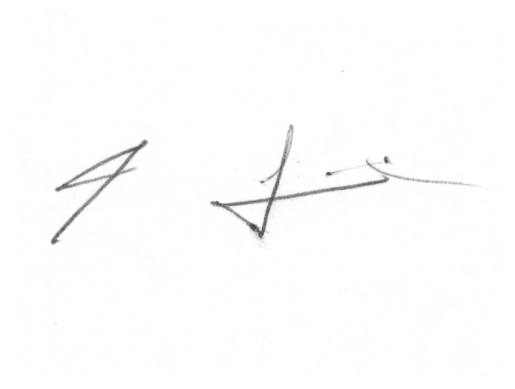

In [13]:
import matplotlib.pyplot as plt
from PIL import Image

# img = Image.open(files[0])

img = Image.open(data_path / "forgeries_1_1.png")

plt.imshow(img, cmap="gray")
plt.axis("off")

(np.float64(-0.5), np.float64(569.5), np.float64(371.5), np.float64(-0.5))

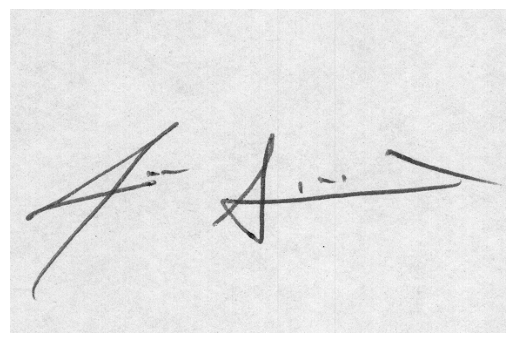

In [14]:
img = Image.open(data_path / "original_1_24.png")
img = Image.open(files[-1])

plt.imshow(img, cmap="gray")
plt.axis("off")

In [15]:
writers

[PosixPath('data/signatures/signatures_34'),
 PosixPath('data/signatures/signatures_37'),
 PosixPath('data/signatures/signatures_25'),
 PosixPath('data/signatures/signatures_11'),
 PosixPath('data/signatures/signatures_40'),
 PosixPath('data/signatures/signatures_50'),
 PosixPath('data/signatures/signatures_54'),
 PosixPath('data/signatures/signatures_18'),
 PosixPath('data/signatures/signatures_22'),
 PosixPath('data/signatures/signatures_21'),
 PosixPath('data/signatures/signatures_15'),
 PosixPath('data/signatures/signatures_51'),
 PosixPath('data/signatures/signatures_49'),
 PosixPath('data/signatures/signatures_48'),
 PosixPath('data/signatures/signatures_47'),
 PosixPath('data/signatures/signatures_20'),
 PosixPath('data/signatures/signatures_38'),
 PosixPath('data/signatures/signatures_39'),
 PosixPath('data/signatures/signatures_45'),
 PosixPath('data/signatures/signatures_23'),
 PosixPath('data/signatures/signatures_6'),
 PosixPath('data/signatures/signatures_9'),
 PosixPath('

In [16]:
# split writers (subject-level split)
import random

random.seed(42)
random.shuffle(writers)

n = len(writers)

train_writers = writers[:int(0.7*n)]
val_writers = writers[int(0.7*n):int(0.85*n)]
test_writers = writers[int(0.85*n):]

print("Train writers:", len(train_writers))
print("Val writers:", len(val_writers))
print("Test writers:", len(test_writers))

Train writers: 38
Val writers: 8
Test writers: 9


In [17]:
# Create dataset folders

base = Path("data")

for split in ["train", "val", "test"]:
    for cls in ["genuine", "forged"]:
        (base / split / cls).mkdir(parents=True, exist_ok=True)

print("Folders created")

Folders created


In [18]:
# copy images into splits

import shutil

def copy_images(writer_list, split):

    for writer in writer_list:

        for img in writer.glob("*.png"):

            name = img.name.lower()

            if "original" in name:
                dst = base / split / "genuine" / img.name

            elif "forgeries" in name:
                dst = base / split / "forged" / img.name

            shutil.copy(img, dst)


copy_images(train_writers, "train")
copy_images(val_writers, "val")
copy_images(test_writers, "test")

print("Dataset split complete")

Dataset split complete


In [19]:
# verify dataset statistics
def count_images(path):
    return len(list(path.glob("*.png")))

for split in ["train", "val", "test"]:

    g = count_images(base / split / "genuine")
    f = count_images(base / split / "forged")

    print(split, "genuine:", g, "forged:", f, "total:", g+f)

train genuine: 912 forged: 912 total: 1824
val genuine: 192 forged: 192 total: 384
test genuine: 216 forged: 216 total: 432


# Pre-Trained Classification Model

In [20]:
# image transformation and normalization
import torchvision.transforms as transforms

In [21]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    # transforms.RandomRotation(5),
    # transforms.RandomAffine(0, translate=(0.02,0.02)),

    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05),
        scale=(0.9,1.1)
    ),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

# test_transform = transforms.Compose([
#     transforms.Resize((224,224)),
#     transforms.Grayscale(num_output_channels=3),
#     transforms.ToTensor()
# ])
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

In [22]:
# load datasets with ImageFolder
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

train_dataset = ImageFolder("data/train", transform=train_transform)
val_dataset = ImageFolder("data/val", transform=test_transform)
test_dataset = ImageFolder("data/test", transform=test_transform)

In [23]:
# create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # each iteration returns 32 samples at a time
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [24]:
# check what is inside
batch = next(iter(train_loader))
print(batch) # the output looks like: (images, labels)

[tensor([[[[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          ...,
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]],

         [[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          ...,
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]],

         [[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, 

In [25]:
batch[0][30] # image of index 30

tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]],

        [[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]],

        [[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]]])

In [26]:
batch[1]

tensor([1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
        1, 0, 1, 1, 0, 0, 0, 1])

In [27]:
images, labels = next(iter(train_loader))

print(images.shape) # ([32, 3, 224, 224]) where 32 is batch size, 3 are the channels (RGB), 224x224 the image size
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


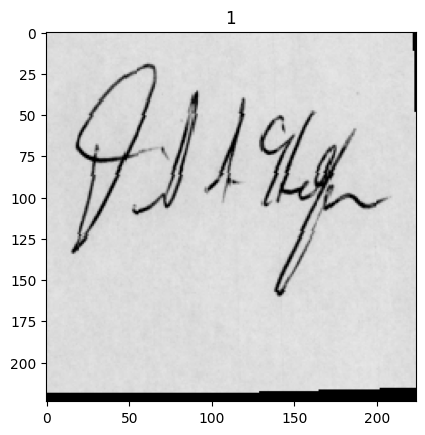

In [28]:
# visualize an image
import matplotlib.pyplot as plt

plt.imshow(images[5].permute(1,2,0)) # from pytorch to matplotlib format
plt.title(labels[5].item())
plt.show()

In [29]:
# check classes
print("Train:", train_dataset.class_to_idx)
print("Val:", val_dataset.class_to_idx)
print("Test:", test_dataset.class_to_idx)

Train: {'forged': 0, 'genuine': 1}
Val: {'forged': 0, 'genuine': 1}
Test: {'forged': 0, 'genuine': 1}


In [30]:
# Load DenseNet
import torch
import torch.nn as nn
import torchvision.models as models

model = models.densenet121(pretrained=True)
# model.classifier = nn.Linear(model.classifier.in_features, 2)

# freeze pretrained layers
for param in model.parameters():
    param.requires_grad = False

# replace classifier
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.classifier.in_features, 2)
)

# allow classifier to train
for param in model.classifier.parameters():
    param.requires_grad = True

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 230MB/s]


In [31]:
# Training Setup
criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# optimizer with weight decay (to add L2 regularization)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)
# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [32]:
device

device(type='cuda')

# Training Loop

In [33]:
# Training Loop
# An epoch = one full pass through the training dataset

for epoch in range(10):
    # Set the model to training mode to enable dropout and batch normalization updates
    model.train()
    # variable to accumulate the loss over the epoch
    running_loss = 0

    # variable to accumulate the loss over the epoch
    for images, labels in train_loader:
        # move the batch to the selected device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass:
        # The images are passed through the network to produce predictions
        outputs = model(images)
        # Compute the loss (CrossEntropyLoss) between predictions and ground truth labels
        loss = criterion(outputs, labels)

        # Reset gradients from the previous iteration
        optimizer.zero_grad()

        # Backpropagation: Compute gradients of the loss with respect to model parameters
        loss.backward()
        # Update model weights using the optimizer
        optimizer.step()
        # Accumulate the batch loss for reporting
        running_loss += loss.item()

    # Print the average loss for the epoch
    print("Epoch:", epoch+1, "Loss:", running_loss/len(train_loader))


Epoch: 1 Loss: 0.7009598926493996
Epoch: 2 Loss: 0.6492997204002581
Epoch: 3 Loss: 0.5876579535634894
Epoch: 4 Loss: 0.5333723425865173
Epoch: 5 Loss: 0.49931316469845016
Epoch: 6 Loss: 0.4723528947746545
Epoch: 7 Loss: 0.44387429063780265
Epoch: 8 Loss: 0.43470070602601035
Epoch: 9 Loss: 0.403794562084633
Epoch: 10 Loss: 0.39083320686691686


# Validation Accuracy

In [34]:
# After training, we evaluate the model on the validation dataset

# Switch the model to evaluation mode
model.eval()

correct = 0 # number of correctly classified samples
total = 0 # total number of samples evaluated

# Disable gradient computation to speed up evaluation and reduce memory usage
with torch.no_grad():

    # Iterate through the validation dataset
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)
        # Forward pass
        outputs = model(images)

        # Get the predicted class index
        # torch.max returns (value, index)
        _, predicted = torch.max(outputs,1)
        # Update total number of samples
        total += labels.size(0)
        # Count how many predictions are correct
        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", correct/total)

Validation Accuracy: 0.8541666666666666


In [36]:
# Switch the model to evaluation mode
model.eval()

correct = 0 # number of correctly classified samples
total = 0 # total number of samples evaluated

# Disable gradient computation to speed up evaluation and reduce memory usage
with torch.no_grad():

    # Iterate through the test dataset
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)
        # Forward pass
        outputs = model(images)

        # Get the predicted class index
        # torch.max returns (value, index)
        _, predicted = torch.max(outputs,1)
        # Update total number of samples
        total += labels.size(0)
        # Count how many predictions are correct
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", correct/total)

Test Accuracy: 0.9768518518518519


In [37]:
# Save the trained model in Colab
torch.save(model.state_dict(), "densenet_cedar.pth")

In [38]:
from google.colab import files
files.download("densenet_cedar.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
# load the model trained in colab
import torch
import torch.nn as nn
import torchvision.models as models

# recreate exact model architecture

model = models.densenet121(pretrained=True)

model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.classifier.in_features, 2)
)

In [ ]:
# Load the checkpoint
checkpoint = torch.load(
    "results/models/densenet_checkpoint.pth",
    map_location="cpu"
)

In [42]:
# Load the weights into the model
model.load_state_dict(checkpoint["model_state"])

<All keys matched successfully>

In [ ]:
model.eval()

In [44]:
# move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

# Explainable AI (XAI)

## Grad-CAM

In [52]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
# Choose the target CNN layer
target_layers = [model.features[-1]]


In [73]:
# Select a test image
img, label = test_dataset[0]
input_tensor = img.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(input_tensor)

pred = torch.argmax(output,1).item()

# Convert class index to class name
class_names = test_dataset.classes
true_label = class_names[label]
pred_label = class_names[pred]

# Generate the Grad-CAM heatmap
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

grayscale_cam = cam(input_tensor=input_tensor)
cam_image = grayscale_cam[0]

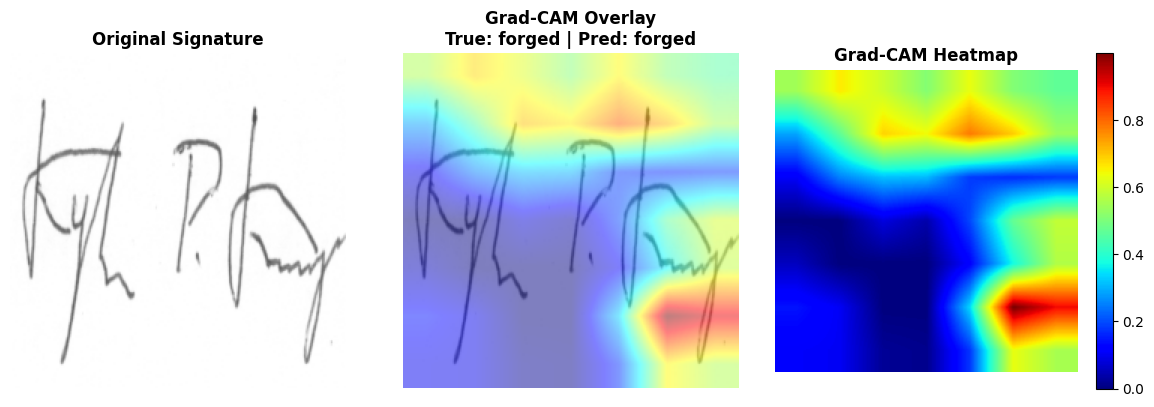

In [88]:
# Overlay the heatmap on the signature

rgb_img = img.permute(1,2,0).numpy()

# Overlay Grad-CAM heatmap on image
visualization = show_cam_on_image(
    rgb_img,
    cam_image,
    use_rgb=True
)

plt.figure(figsize=(12,4))

# Original image
plt.subplot(1,3,1)
plt.imshow(rgb_img)
plt.title("Original Signature", fontsize=12, fontweight="bold")
plt.axis("off")

# Overlay
plt.subplot(1,3,2)
plt.imshow(visualization)
plt.title(f"Grad-CAM Overlay\nTrue: {true_label} | Pred: {pred_label}", fontsize=12, fontweight="bold")
plt.axis("off")

# Heatmap with real importance scale
plt.subplot(1,3,3)
heatmap = plt.imshow(cam_image, cmap="jet")
plt.title("Grad-CAM Heatmap", fontsize=12, fontweight="bold")
plt.axis("off")
plt.colorbar(heatmap)

plt.tight_layout()
plt.show()